In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
from functools import partial

from IPython.display import display, Markdown, Image
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase

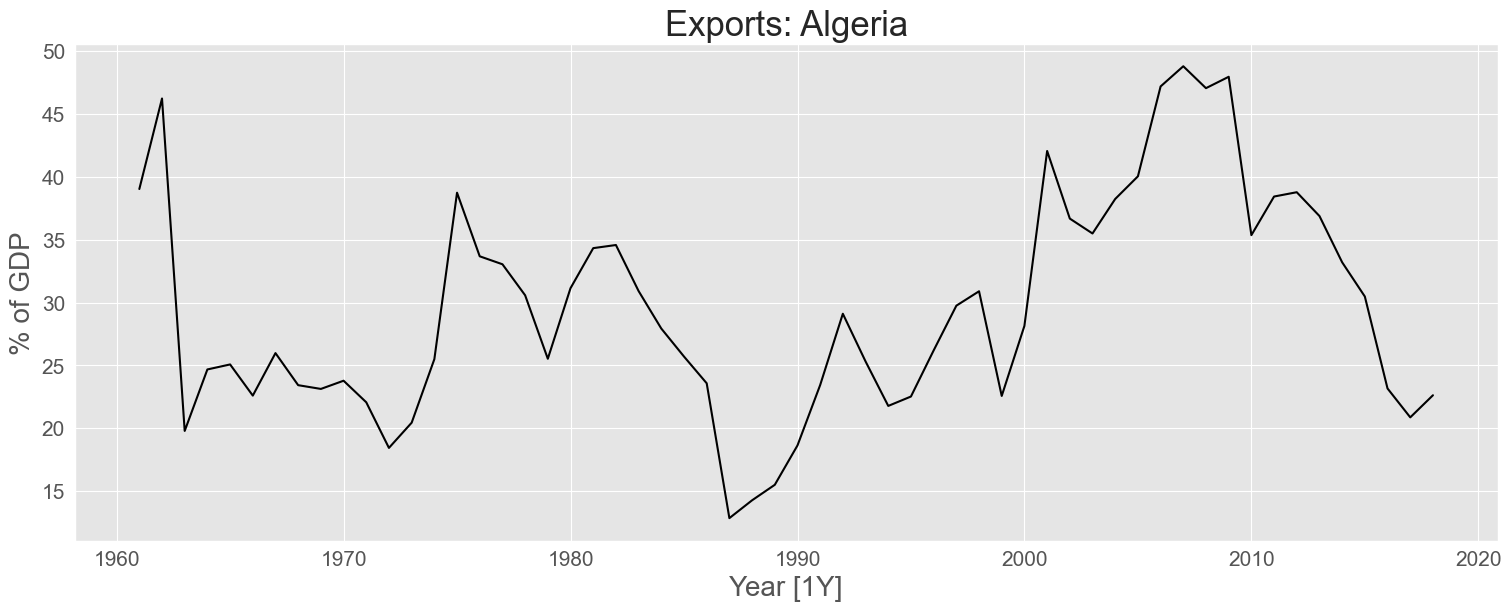

In [4]:
algeria_economy = pd.read_csv("algeria_exports.csv",
    parse_dates=["ds"])
plt.rcParams["figure.figsize"] = (8, 4.3)
plot_series(algeria_economy,
    xlabel="Year [1Y]", ylabel="% of GDP", title="Exports: Algeria")

In [5]:
sf = StatsForecast(freq="Y",
    models=[AutoETS(model="ANN", alias="SES")])

fc = sf.forecast(df=algeria_economy, h=5, level=[80, 95], fitted=True)
fc.head()

,unique_id,ds,SES,SES-lo-95,SES-lo-80,SES-hi-80,SES-hi-95
0,Algeria,2018-12-31,22.442,10.523,14.648,30.235,34.361
1,Algeria,2019-12-31,22.442,6.875,12.263,32.620,38.009
2,Algeria,2020-12-31,22.442,3.933,10.339,34.544,40.951
3,Algeria,2021-12-31,22.442,1.398,8.682,36.202,43.486
4,Algeria,2022-12-31,22.442,-0.863,7.204,37.680,45.746


In [6]:
fitted_vals = sf.forecast_fitted_values()
fitted_vals.head()

,unique_id,ds,y,SES,SES-lo-95,SES-lo-80,SES-hi-80,SES-hi-95
0,Algeria,1960-12-31,39.043,39.530,27.720,31.808,47.252,51.340
1,Algeria,1961-12-31,46.245,39.121,27.311,31.399,46.843,50.931
2,Algeria,1962-12-31,19.794,45.105,33.295,37.383,52.828,56.916
3,Algeria,1963-12-31,24.685,23.842,12.031,16.119,31.564,35.652
4,Algeria,1964-12-31,25.084,24.550,12.740,16.828,32.272,36.360


In [7]:
# Save model fit(s)
sf.fit(algeria_economy)
# Save model fit(s) and return forecasts
fc = sf.fit_predict(df=algeria_economy, h=5, level=[80, 95])
params = sf.fitted_[0, 0].model_["fit"].x
alpha, level_0 = np.round(params, 4)

In [8]:
ses = AutoETS(model="ANN", alias="SES")
ses.fit(y=algeria_economy["y"].values)
params = ses.model_["fit"].x
alpha, level_0 = np.round(params, 4)
print("Optimal parameters:")
print("alpha:", alpha)
print("Initial level:", level_0)

Optimal parameters:
alpha: 0.8401
Initial level: 39.53


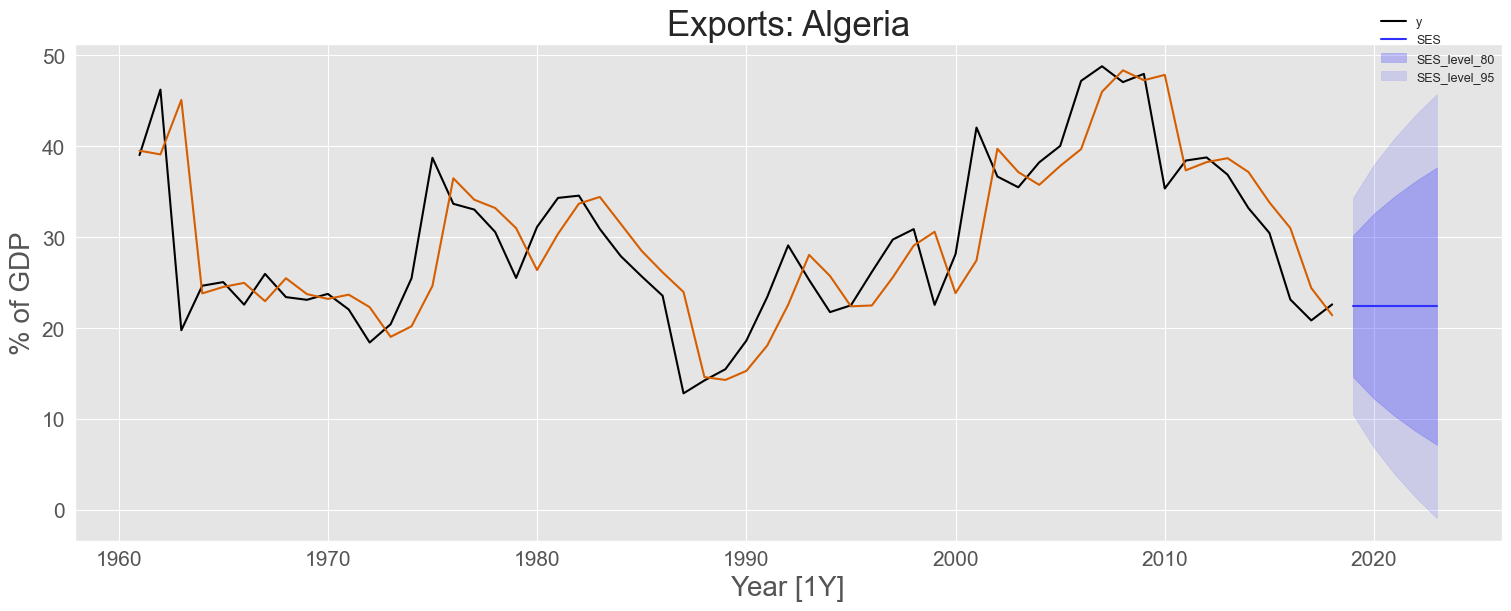

In [10]:
fig = plot_series(algeria_economy, fc, level=[80, 95],
    xlabel="Year [1Y]", ylabel="% of GDP", title="Exports: Algeria",
    palette="black_and_blue", rm_legend=False)
fig.axes[0].plot("ds", "SES", data=fitted_vals, color="#D55E00")
fig